# Per-SPI baselines on the 1,053-record corpus

Companion to the [baseline notebook](spi_baseline_exploration_260921.ipynb). This is a descriptive comparison of common spaces, not a claim that one arrangement is scientifically superior. All three views use the same 1,053 recordings and the same seeded p90 run. No new SPIs are computed.

The source archive stores arrays as M × T, with M=5–29 and T=30–3000. The original runner z-scored channels. Ordered off-diagonal entries retain both directions. Each MPI contributes its mean, or seven marginal summaries; SPI–SPI uses the existing 41,616 Pearson cross-statistic correlations.

Preprocessing is fitted **transductively on all 1,053 rows**: 95% feature validity, median imputation, SD scaling and clipping at ±5 SD for marginals; centre-only for z; then PCA50 and UMAP with 30 neighbours, min_dist=.1, seed260824. These are matched working recipes, not a parameter search. The z map is a new view using this declared recipe, not an exact reconstruction of every historical explorer view.

In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scripts.spi_baseline_exploration import OUT, DATA
from scripts import plot_spi_baseline_exploration as plots
plots.style()
pd.set_option("display.max_colwidth", 60)


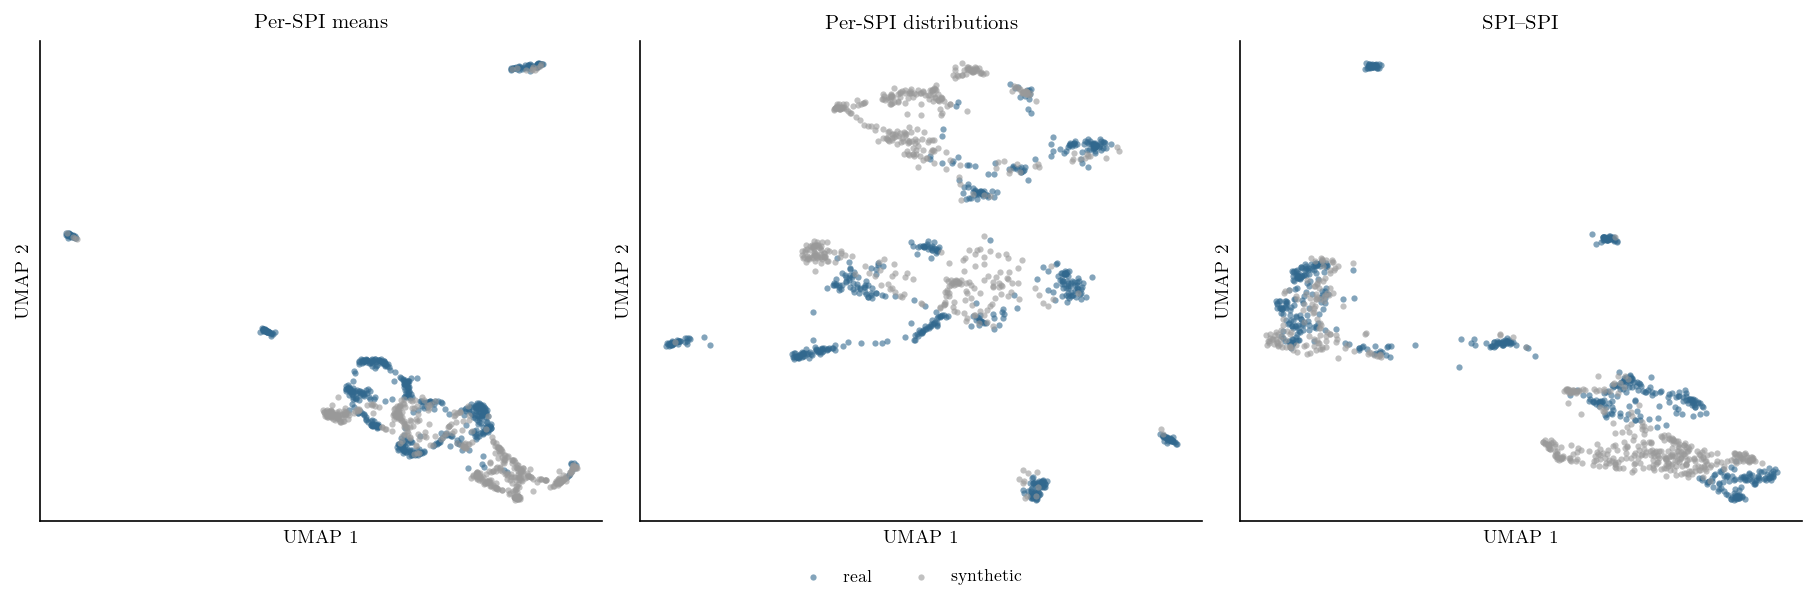

In [2]:
fig = plots.zenodo('origin')
plt.show()

Colour is source origin, using the existing corrected metadata (566 real, 487 synthetic). Origin is an annotation, not an independent definition of dynamical similarity. Separating real and synthetic recordings more strongly is not automatically a better representation. Axes, rotations and cluster gaps are not comparable numerical quantities between independently fitted maps.

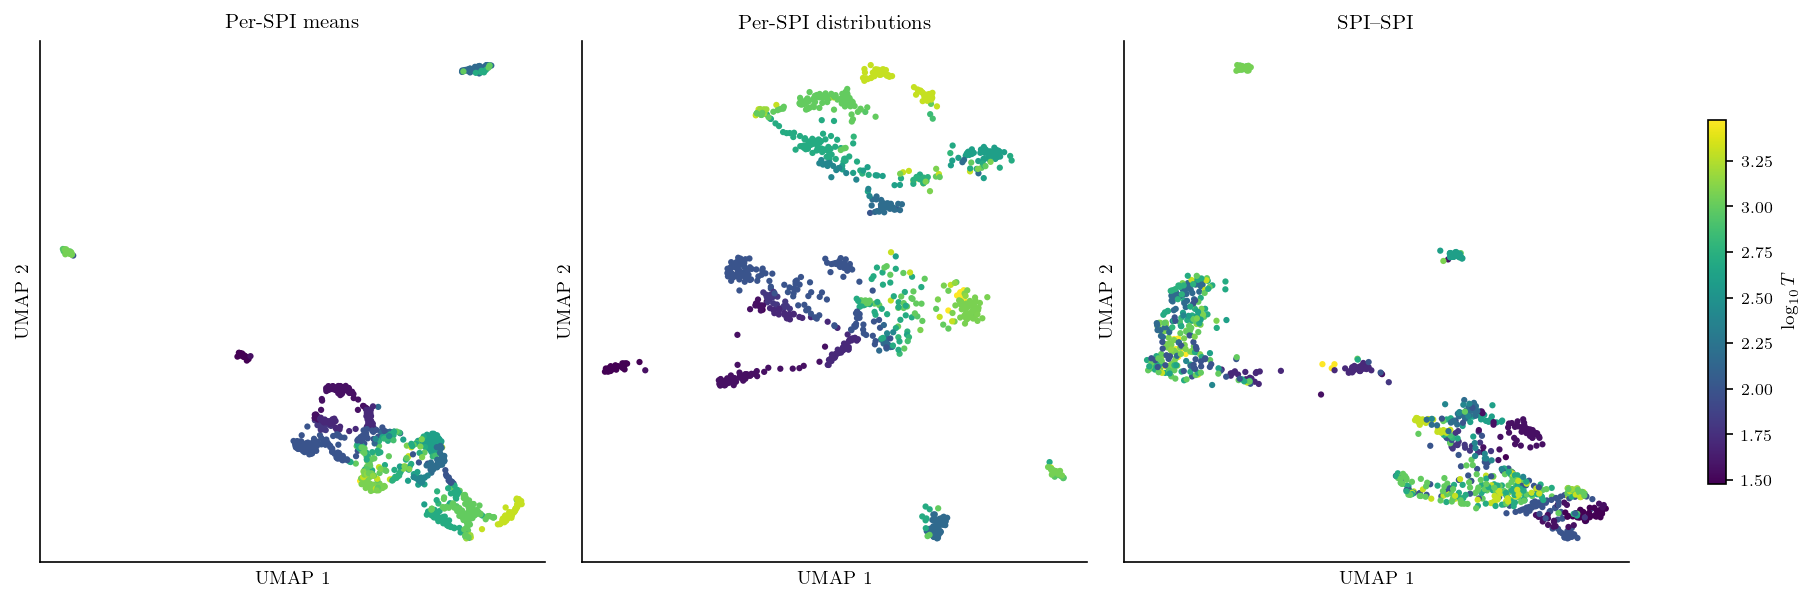

In [3]:
fig = plots.zenodo('duration')
plt.show()

In [4]:
display(pd.read_csv(OUT / 'zenodo-descriptive.csv').round(3))

,method,retained,explained_variance,abs_PC1_M,abs_PC1_T
0,mean,235,0.984,0.202,0.207
1,distribution,1701,0.944,0.212,0.272
2,z,21788,0.725,0.270,0.024


The table reports variance captured by PCA50 and absolute Spearman correlations of PC1 with M and T. These are limited nuisance diagnostics, not tests of invariance: size information can live outside PC1. The duration colouring exposes one possible organizing factor without making a mechanistic interpretation.

No cluster-quality score is used here because the corpus has no single validated partition of dynamical mechanisms. Source labels are multi-label; duplicates and nested windows also complicate independence. A defensible next comparison requires an external scientific task or a prespecified set of relations to recover. Agreement with z's own clusters would be circular evidence for z.

The established [interactive explorer](../../results/zenodo_7118947/visual-exploration-v2/index.html) remains useful for inspecting individual recordings and source groups. Its geometry need not match these new panels. Primary sources: [Cliff et al.](https://arxiv.org/abs/2201.11941) for the SPI library/corpus; [Navarro et al.](https://proceedings.mlr.press/v224/navarro23a/navarro23a.pdf) for an existing alternative based on fixed-length pooled Catch22 descriptors.

Reproduce with `python -m scripts.spi_baseline_exploration zenodo` from the repository root. It reads only the seed1729 MPI bank. Compact arrays, source hashes and descriptive metrics are saved under `results/spi_baseline_exploration_260921/`; the exact formulas and remaining comparisons are in the main notebook.